In [15]:
# Notebook to plot geolocated data infrared radiances a) Full disk b) sub-saharan africa domain

In [1]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import glob
import os
from pyproj import CRS, Transformer
import cartopy.crs as ccrs


In [2]:

for filepath in glob.glob("FCI*.nc"):
    print(filepath)



FCIL1FDHSI_20260331T095052Z_20260331T095752Z_epct_f12870b7_FC.nc
FCIL1FDHSI_20260331T095003Z_20260331T095935Z_epct_9d878629_F.nc


In [3]:
ds = xr.open_dataset(filepath)
tir = ds['ir_105_effective_radiance'].astype("float32")
tir = tir.where(tir != 65535)



In [4]:
ds

<xarray.Dataset> Size: 125MB
Dimensions:                    (y: 5607, x: 5568)
Coordinates:
  * y                          (y) float64 45kB -5.565e+06 ... 5.566e+06
  * x                          (x) float64 45kB -5.566e+06 ... 5.566e+06
Data variables:
    geostationary              |S1 1B ...
    ir_105_effective_radiance  (y, x) float32 125MB ...
Attributes: (12/90)
    Conventions:                          CF-1.7
    algorithm_version:                    5.13.0
    cdm_datatype:                         CDM version 4
    component1:                           CHK
    component2:                           TRAIL
    count_in_repeat_cycle:                0041
    ...                                   ...
    EPCT_roi:                             null
    EPCT_sensing_start:                   null
    EPCT_sensing_stop:                    null
    EPCT_software_name:                   DataTailor
    EPCT_software_version:                3.5.4
    EPCT_stretch_method:                  null

In [5]:
# estimate coords for geolocation

x = ds["x"].values
y = ds["y"].values
X, Y = np.meshgrid(x, y)

gm = ds["geostationary"]

# --------------------------------------------------
# BUILD GEOSTATIONARY CRS (CF-compliant)
# --------------------------------------------------

crs_geo = CRS.from_cf(gm.attrs)
crs_ll  = CRS.from_epsg(4326)

transformer = Transformer.from_crs(
    crs_geo,
    crs_ll,
    always_xy=True
)

# --------------------------------------------------
# INVERSE PROJECTION
# (let PROJ return inf for invalid pixels)
# --------------------------------------------------

lon, lat = transformer.transform(
    X,
    Y,
    errcheck=False   # IMPORTANT
)

# --------------------------------------------------
# MASK INVALID GEOMETRY
# --------------------------------------------------

invalid = ~np.isfinite(lon) | ~np.isfinite(lat)

lon[invalid] = np.nan
lat[invalid] = np.nan

print(np.nanmin(lat), np.nanmax(lat))
print(np.nanmin(lon), np.nanmax(lon))


-81.0832411513727 81.07438876091007
-81.2353665246638 81.23536652486196


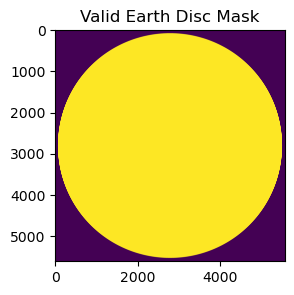

In [6]:
# lat disk mask for checking
plt.figure(figsize=(3,3))
plt.imshow(np.isfinite(lat), origin="upper")
plt.title("Valid Earth Disc Mask")
plt.show()


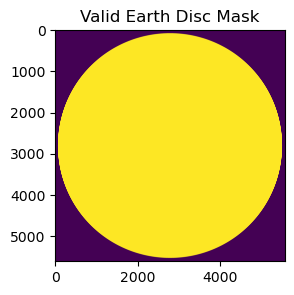

In [7]:
# lon disk mask for checking
plt.figure(figsize=(3,3))
plt.imshow(np.isfinite(lon), origin="upper")
plt.title("Valid Earth Disc Mask")
plt.show()


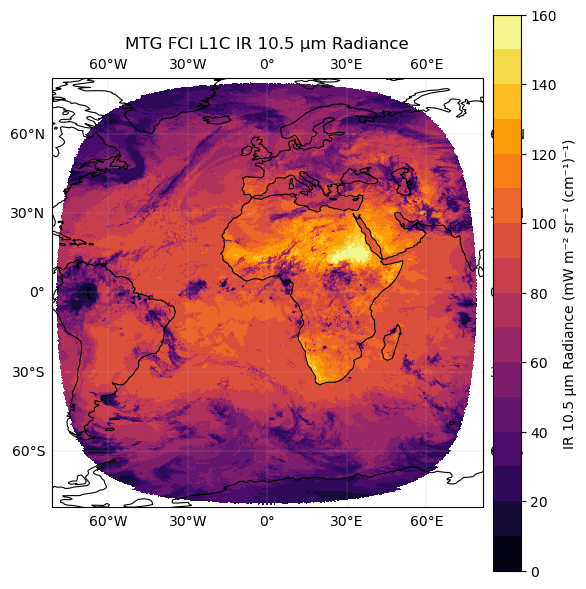

In [8]:
# plot the geolocated data

# Mask invalid pixels (outside Earth disk)
mask = np.isnan(lat) | np.isnan(lon) | np.isnan(tir)
rad_masked = np.ma.masked_where(mask, tir)


# SET CONTOUR LEVELS
# --------------------------------------------------

levels = np.arange(0,170,10)

# --------------------------------------------------
# CREATE MAP
# --------------------------------------------------

plt.figure(figsize=(6, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Filled contours
cf = ax.contourf(
    lon,
    lat,
    rad_masked,
    levels=levels,
    cmap="inferno",
    transform=ccrs.PlateCarree()
)

# --------------------------------------------------
# MAP DECORATION
# --------------------------------------------------

ax.coastlines(resolution="110m", linewidth=0.8)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

ax.set_extent(
    [
        np.nanmin(lon),
        np.nanmax(lon),
        np.nanmin(lat),
        np.nanmax(lat)
    ],
    crs=ccrs.PlateCarree()
)

# Colorbar
cbar = plt.colorbar(cf, pad=0.02)
cbar.set_label("IR 10.5 µm Radiance (mW m⁻² sr⁻¹ (cm⁻¹)⁻¹)")

plt.title("MTG FCI L1C IR 10.5 µm Radiance")
plt.tight_layout()
plt.show()


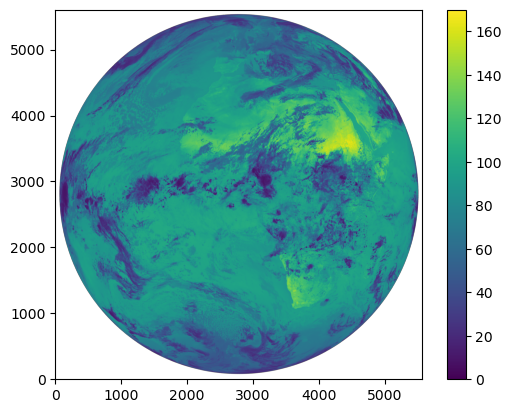

In [9]:
# plot original data
a = plt.imshow(tir,vmin=0,vmax=170,origin= 'lower')
plt.colorbar(a)

In [10]:
# save coords to netcdf

ny, nx = lat.shape[0], lat.shape[1]

y = np.arange(ny)
x = np.arange(nx)

# Replace NaNs with fill value
fill_value = -9999.0
lon_masked = np.nan_to_num(lon, nan=fill_value)
lat_masked = np.nan_to_num(lat, nan=fill_value)


# Create dataset
ds = xr.Dataset(
    {
        "latitude": (("y", "x"), lat_masked),
        "longitude": (("y", "x"), lon_masked),
    },
    coords={"x": x, "y": y},
)


# Save to NetCDF
ds.to_netcdf(
    "MTG_FullDisk_lat_lon.nc",
    encoding={
        "latitude": {"_FillValue": fill_value},
        "longitude": {"_FillValue": fill_value},
    },
)


In [12]:
# plot the sub-saharan africa file 

for filepath in glob.glob("FCI*FC.nc"):
    print(filepath)

ds = xr.open_dataset(filepath)
tir = ds['ir_105_effective_radiance'].astype("float32")
tir = tir.where(tir != 65535)


x = ds["x"].values
y = ds["y"].values
X, Y = np.meshgrid(x, y)

gm = ds["geostationary"]

# --------------------------------------------------
# BUILD GEOSTATIONARY CRS (CF-compliant)
# --------------------------------------------------

crs_geo = CRS.from_cf(gm.attrs)
crs_ll  = CRS.from_epsg(4326)

transformer = Transformer.from_crs(
    crs_geo,
    crs_ll,
    always_xy=True
)

# --------------------------------------------------
# INVERSE PROJECTION
# (let PROJ return inf for invalid pixels)
# --------------------------------------------------

lon, lat = transformer.transform(
    X,
    Y,
    errcheck=False   # IMPORTANT
)

# --------------------------------------------------
# MASK INVALID GEOMETRY
# --------------------------------------------------

invalid = ~np.isfinite(lon) | ~np.isfinite(lat)

lon[invalid] = np.nan
lat[invalid] = np.nan

print(np.nanmin(lat), np.nanmax(lat))
print(np.nanmin(lon), np.nanmax(lon))


FCIL1FDHSI_20260331T095052Z_20260331T095752Z_epct_f12870b7_FC.nc
-41.874073405136876 27.216063236219984
-27.16048142265777 79.44940147592028


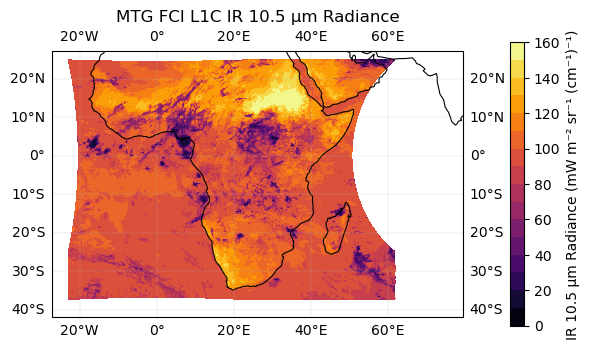

In [13]:
# plot geolocated data

# Mask invalid pixels (outside Earth disk)
mask = np.isnan(lat) | np.isnan(lon) | np.isnan(tir)
rad_masked = np.ma.masked_where(mask, tir)


# SET CONTOUR LEVELS
# --------------------------------------------------

levels = np.arange(0,170,10)

# --------------------------------------------------
# CREATE MAP
# --------------------------------------------------

plt.figure(figsize=(6, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Filled contours
cf = ax.contourf(
    lon,
    lat,
    rad_masked,
    levels=levels,
    cmap="inferno",
    transform=ccrs.PlateCarree()
)

# --------------------------------------------------
# MAP DECORATION
# --------------------------------------------------

ax.coastlines(resolution="110m", linewidth=0.8)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

ax.set_extent(
    [
        np.nanmin(lon),
        np.nanmax(lon),
        np.nanmin(lat),
        np.nanmax(lat)
    ],
    crs=ccrs.PlateCarree()
)

# Colorbar
cbar = plt.colorbar(cf, pad=0.1,fraction=0.03)
cbar.set_label("IR 10.5 µm Radiance (mW m⁻² sr⁻¹ (cm⁻¹)⁻¹)")

plt.title("MTG FCI L1C IR 10.5 µm Radiance")
plt.tight_layout()
plt.show()


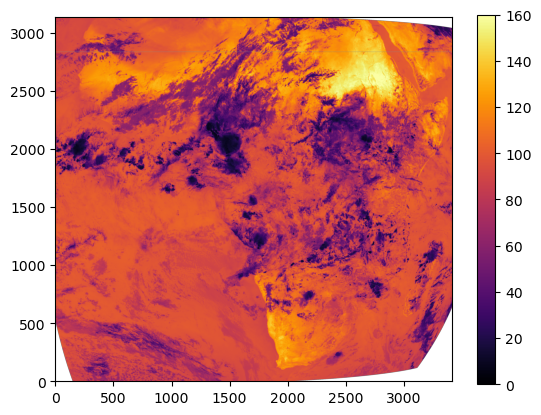

In [14]:
# original raw data
a = plt.imshow(tir,vmin=0,vmax=160,origin= 'lower',cmap='inferno')
plt.colorbar(a)

In [5]:
# save coords to netcdf
ny, nx = lat.shape[0], lat.shape[1]

y = np.arange(ny)
x = np.arange(nx)

# Replace NaNs with fill value
fill_value = -9999.0
lon_masked = np.nan_to_num(lon, nan=fill_value)
lat_masked = np.nan_to_num(lat, nan=fill_value)


# Create dataset
ds = xr.Dataset(
    {
        "latitude": (("y", "x"), lat_masked),
        "longitude": (("y", "x"), lon_masked),
    },
    coords={"x": x, "y": y},
)


# Save to NetCDF
ds.to_netcdf(
    "MTG_SSA_lat_lon.nc",
    encoding={
        "latitude": {"_FillValue": fill_value},
        "longitude": {"_FillValue": fill_value},
    },
)
